In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler



# pipeline

# Replicate Grouping

Im calling discrete factors "blocks" because im stupid. Soon I will look at encoding these and using them as features for GP but Idk if that is a valid approach

In [2]:
def group(data, controlVars, outputVar, blockVar=None, outlierSD=None):
    groups = []
    dropped_groups = []

    group_cols = controlVars if blockVar is None else [blockVar] + controlVars

    for keys, g in data.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        y = g[outputVar].astype(float)

        # outlier filter
        if outlierSD is not None and len(y) > 2:
            m = y.mean()
            s = y.std()

            if s > 0:
                mask = np.abs(y - m) <= outlierSD * s
                g = g[mask]
                y = g[outputVar].astype(float)

        count = len(y)

        # drop if less than 2 points
        if count < 2:
            dropped_groups.append(keys)
            continue

        row = {
            **dict(zip(group_cols, keys)),
            "mean": y.mean(),
            "std": y.std(),
            "count": count
        }
        groups.append(row)

    summary = pd.DataFrame(groups)

    if dropped_groups:
        print(f"Warning: dropping {len(dropped_groups)} groups with <2 replicates")

    if blockVar is None:
        return summary.reset_index(drop=True)

    return {
        block: df_block.reset_index(drop=True)
        for block, df_block in summary.groupby(blockVar)
    }

# Fit GP

In [3]:
def fit_gp(df, controlVars, kernel=None, outputVar=None, logVars=None, noise="std"):
    logVars = logVars or []

    X = df[controlVars].copy().astype(float)
    for col in logVars:
        X[col] = np.log10(X[col])

    if outputVar == None:
        y = df["mean"].to_numpy(dtype=float)
    else:
        y = df[outputVar].to_numpy(dtype=float)

    if noise == "sem":
        alpha = (df["std"].to_numpy(dtype=float) / np.sqrt(df["count"].to_numpy(dtype=float))) ** 2
    elif noise == "std":
        alpha = df["std"].to_numpy(dtype=float) ** 2
    elif noise == "constant":
        alpha = 5e-2
    else:
        raise ValueError("noise must be 'std', 'sem' and constant")

    if kernel == None:
        kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(
            length_scale=np.ones(len(controlVars)),
            length_scale_bounds=(0.5, 5)
        )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha,
        normalize_y=True,
        n_restarts_optimizer=5
    )

    gp.fit(X.to_numpy(), y)
    print("kernel =", gp.kernel_)
    return gp

# 1D slice

In [4]:
def plot_gp(df, gp, controlVars, xVar, yVar="mean", logVars=None, fixedVals=None, title=None):
    logVars = logVars or []
    fixedVals = fixedVals or {}

    x_raw = np.sort(df[xVar].astype(float).unique())
    x_grid = np.geomspace(x_raw.min(), x_raw.max(), 300) if xVar in logVars else np.linspace(x_raw.min(), x_raw.max(), 300)

    X_pred_rows = []
    for x in x_grid:
        row = {}
        for col in controlVars:
            if col == xVar:
                row[col] = x
            elif col in fixedVals:
                row[col] = fixedVals[col]
            else:
                row[col] = df[col].median()
        X_pred_rows.append(row)

    X_pred = np.array([[row[col] for col in controlVars] for row in X_pred_rows], dtype=float)

    for i, col in enumerate(controlVars):
        if col in logVars:
            X_pred[:, i] = np.log10(X_pred[:, i])

    y_pred, y_std = gp.predict(X_pred, return_std=True)

    plot_df = df.copy()
    for col, val in fixedVals.items():
        plot_df = plot_df[plot_df[col] == val]

    plt.figure(figsize=(8, 4))
    plt.scatter(plot_df[xVar], plot_df[yVar], color='red', label='Training Data')
    plt.plot(x_grid, y_pred, color='black', label='Predicted Mean')
    plt.fill_between(
        x_grid,
        y_pred - 1.96 * y_std,
        y_pred + 1.96 * y_std,
        color='gray',
        alpha=0.35,
        label='95% Confidence Interval'
    )

    if xVar in logVars:
        plt.xscale('log')

    plt.xlabel(xVar)
    plt.ylabel(yVar)
    if title:
        plt.title(title)
    plt.legend()
    plt.show()

## 2D plot

In [44]:
def plot_gp_2d(df, gp, controlVars, xVar, yVar, logVars=None, n_grid=100):
    logVars = logVars or []

    x_raw = df[xVar].astype(float).to_numpy()
    y_raw = df[yVar].astype(float).to_numpy()

    x_grid = np.geomspace(x_raw.min(), x_raw.max(), n_grid) if xVar in logVars else np.linspace(x_raw.min(), x_raw.max(), n_grid)
    y_grid = np.geomspace(y_raw.min(), y_raw.max(), n_grid) if yVar in logVars else np.linspace(y_raw.min(), y_raw.max(), n_grid)

    XX, YY = np.meshgrid(x_grid, y_grid)

    pred_df = {}
    for col in controlVars:
        if col == xVar:
            pred_df[col] = XX.ravel()
        elif col == yVar:
            pred_df[col] = YY.ravel()
        else:
            pred_df[col] = np.full(XX.size, df[col].median())

    X_pred = np.column_stack([pred_df[col] for col in controlVars]).astype(float)

    for i, col in enumerate(controlVars):
        if col in logVars:
            X_pred[:, i] = np.log10(X_pred[:, i])

    y_pred, y_std = gp.predict(X_pred, return_std=True)

    Z_mean = y_pred.reshape(XX.shape)
    Z_std = y_std.reshape(XX.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(XX, YY, Z_mean, levels=40)
    plt.scatter(df[xVar], df[yVar], c=df['mean'], edgecolors='k')
    if xVar in logVars:
        plt.xscale('log')
    if yVar in logVars:
        plt.yscale('log')
    plt.xlabel(xVar)
    plt.ylabel(yVar)
    plt.title("GP Predicted Mean")
    plt.colorbar(label='mean')
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.contourf(XX, YY, Z_std, levels=40)
    plt.scatter(df[xVar], df[yVar], color='red', edgecolors='k')
    if xVar in logVars:
        plt.xscale('log')
    if yVar in logVars:
        plt.yscale('log')
    plt.xlabel(xVar)
    plt.ylabel(yVar)
    plt.title("GP Uncertainty")
    plt.colorbar(label='std')
    plt.show()

# 1D Plot with additives encoded as one hot

In [45]:
df = pd.read_csv('data/cleaned_data_no_control.csv')

# Feature engineering
df['rxn_concentration'] = df['concentration'] * df['volume']

# Scaling
#scaler = StandardScaler()
#df['rxn_concentration'] = scaler.fit_transform(df[['rxn_concentration']])

y_scaler = StandardScaler()
df['lambda max wavelength'] = y_scaler.fit_transform(df[['lambda max wavelength']])

# one hot encode additive
df = pd.get_dummies(df, columns=['additive'], prefix='add')
additive_cols = [c for c in df.columns if c.startswith("add_")]

# combine control variables
control_vars = ['rxn_concentration'] + additive_cols

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(0.5, 10.0),
    nu=1.5
)

gp_data = group(
    data=df,
    controlVars=control_vars,
    outputVar='lambda max wavelength'
)
gp_data.head()

,rxn_concentration,add_C1,add_C4,add_C5,add_C6,add_C7,add_C8,add_nitrate,mean,std,count
0,0.00,False,False,False,False,False,False,True,0.280397,0.057553,6
1,0.02,False,False,False,False,False,True,False,0.075532,0.014682,2
2,0.02,False,False,False,True,False,False,False,0.130347,0.056966,2
3,0.02,False,True,False,False,False,False,False,-0.163248,0.093965,2
4,0.02,True,False,False,False,False,False,False,-0.282845,0.263101,2


kernel = 10**2 * Matern(length_scale=0.5, nu=1.5)


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


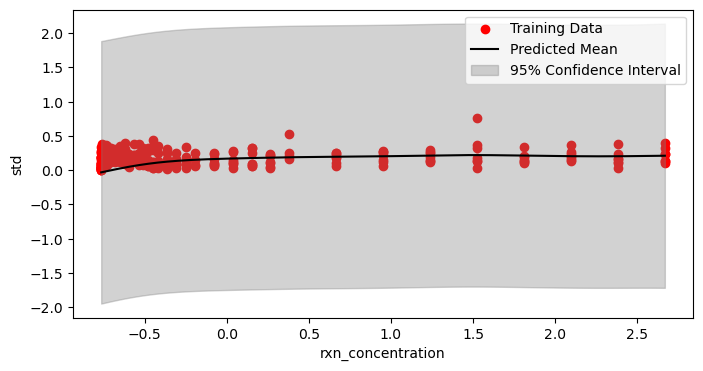

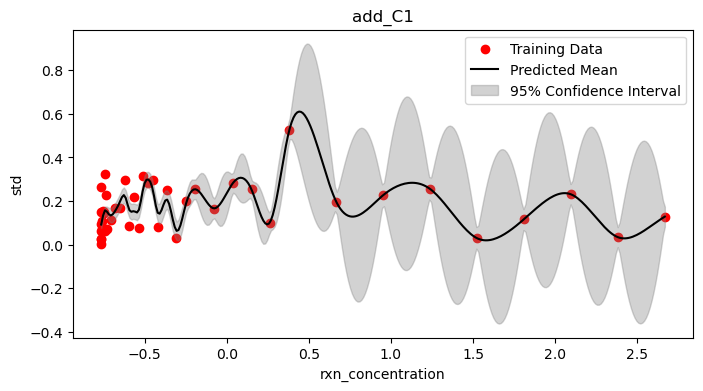

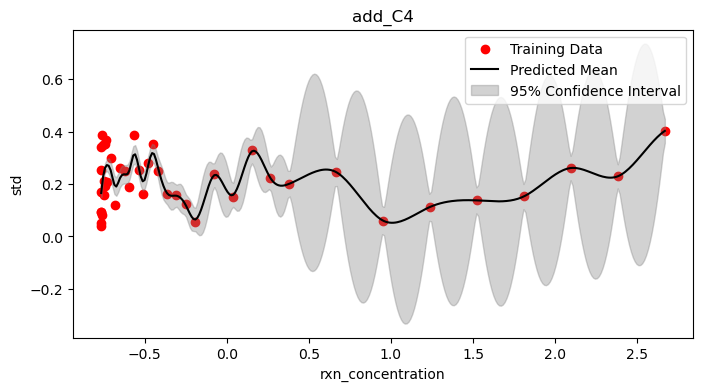

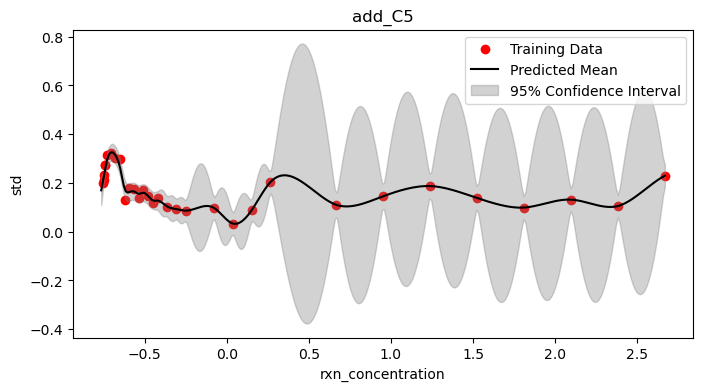

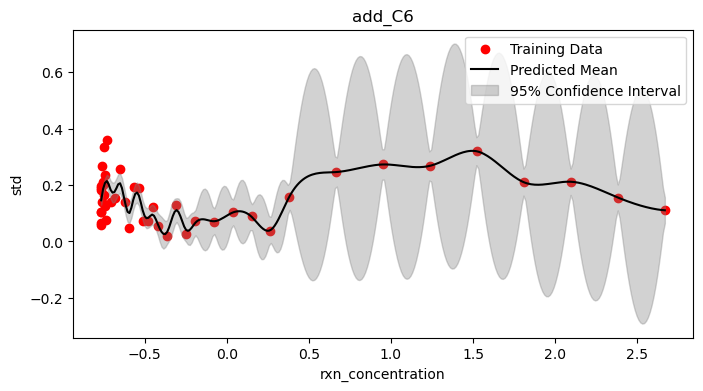

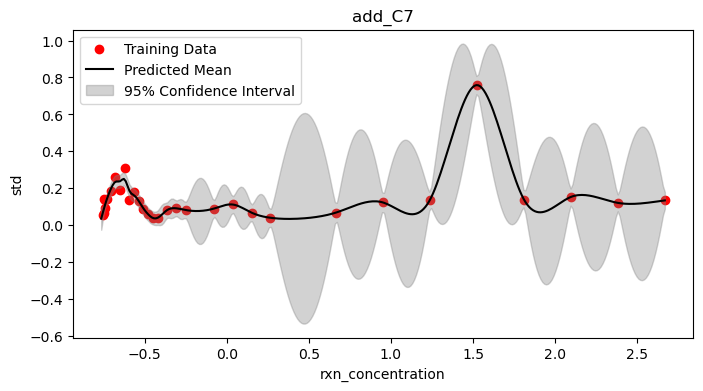

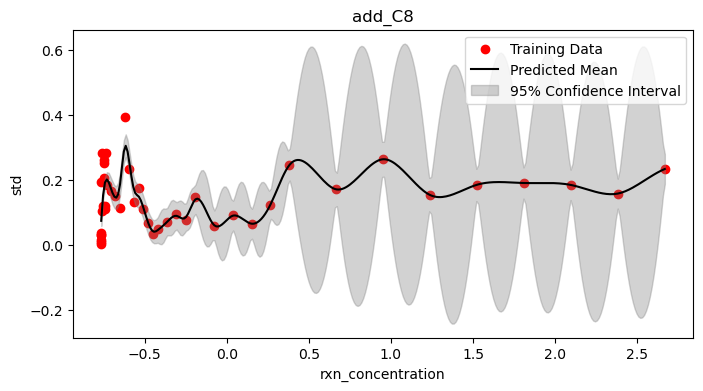

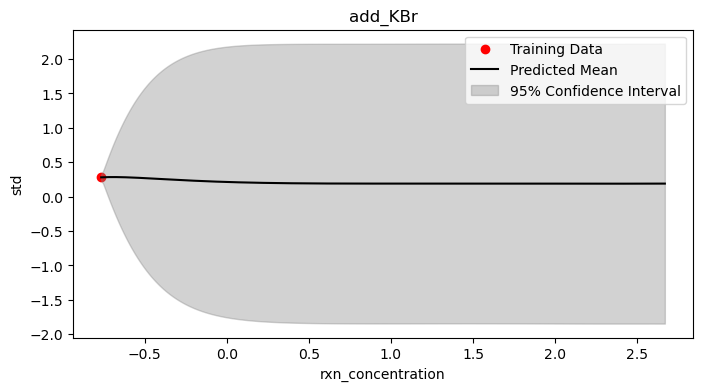

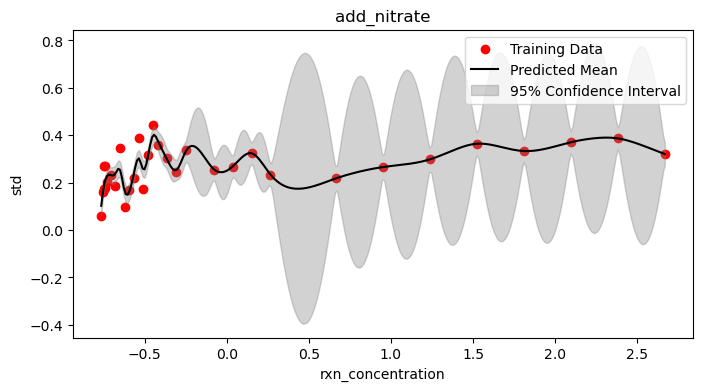

10**2 * Matern(length_scale=0.5, nu=1.5)


In [50]:
df = pd.read_csv('data/output.csv')

# Feature engineering
df['rxn_concentration'] = df['concentration'] * df['volume']

# Scaling
scaler = StandardScaler()
df['rxn_concentration'] = scaler.fit_transform(df[['rxn_concentration']])

y_scaler = StandardScaler()
df['lambda max wavelength'] = y_scaler.fit_transform(df[['lambda max wavelength']])

# one hot encode additive
df = pd.get_dummies(df, columns=['additive'], prefix='add')
additive_cols = [c for c in df.columns if c.startswith("add_")]

# combine control variables
control_vars = ['rxn_concentration'] + additive_cols

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(0.5, 10.0),
    nu=1.5
)

gp_data = group(
    data=df,
    controlVars=control_vars,
    outputVar='lambda max wavelength'
)

gp = fit_gp(
    gp_data,
    controlVars=control_vars,
    kernel=kernel,
    outputVar="std",
    noise="constant"
)

plot_gp(
        gp_data,
        gp,
        controlVars=control_vars,
        yVar='std',
        xVar='rxn_concentration',
    )

for add in additive_cols:
    fixedVals = {col: 0 for col in additive_cols}
    fixedVals[add] = 1

    plot_gp(
        gp_data,
        gp,
        controlVars=control_vars,
        xVar='rxn_concentration',
        yVar='std',
        fixedVals=fixedVals,
        title=add
    )
    

print(gp.kernel_)

kernel = 1.13**2 * Matern(length_scale=0.821, nu=1.5)


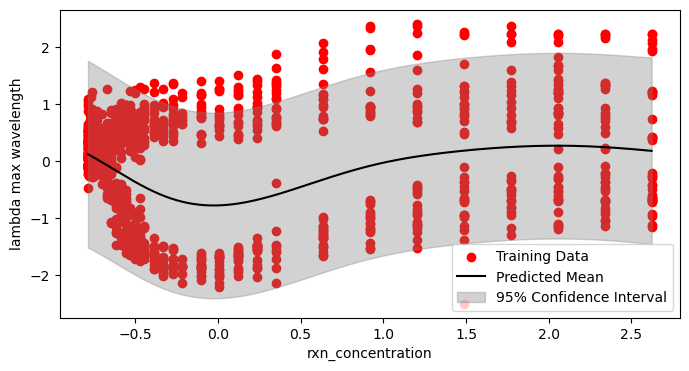

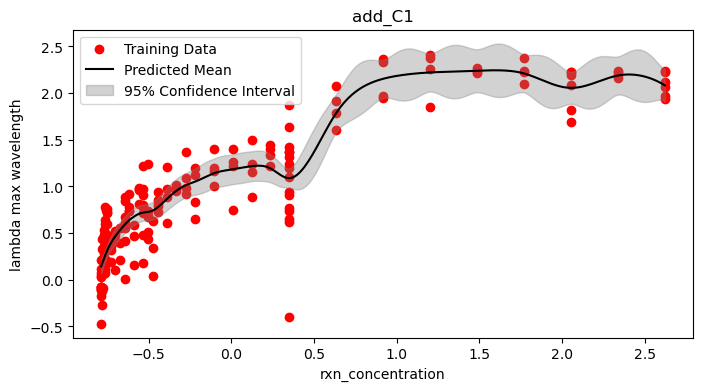

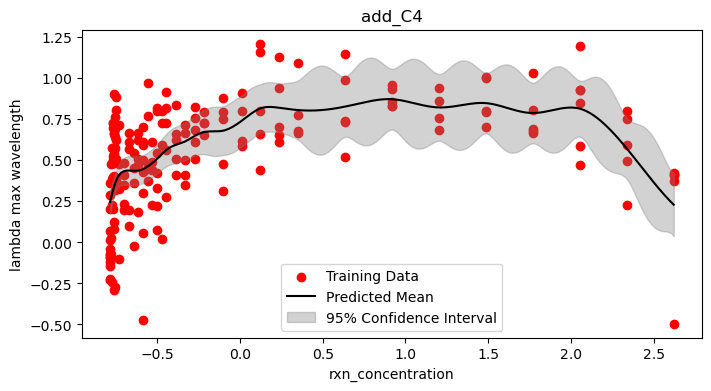

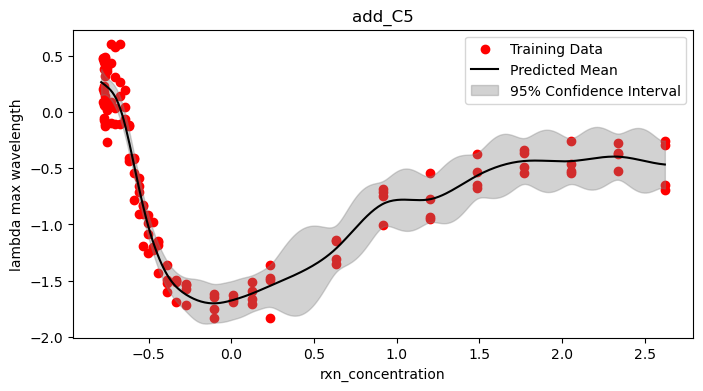

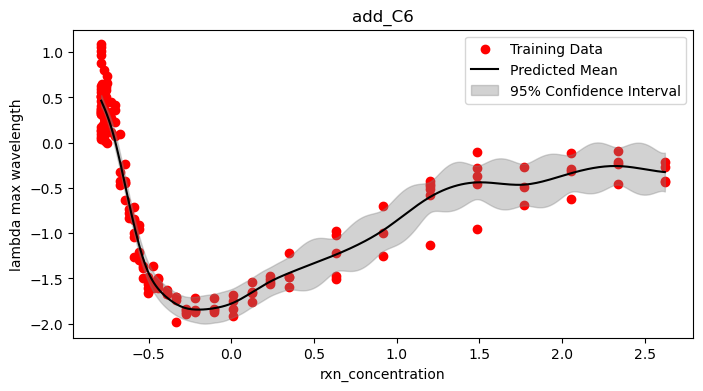

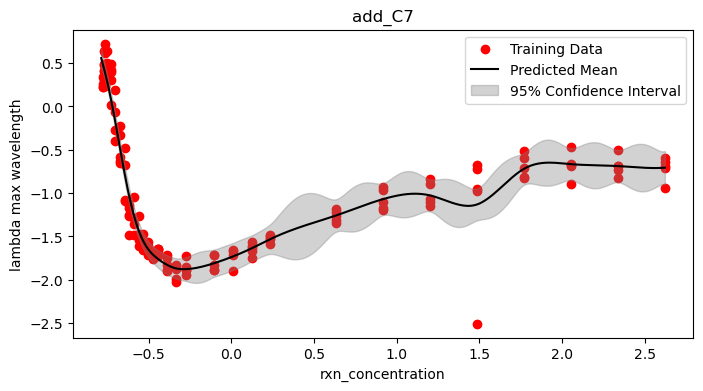

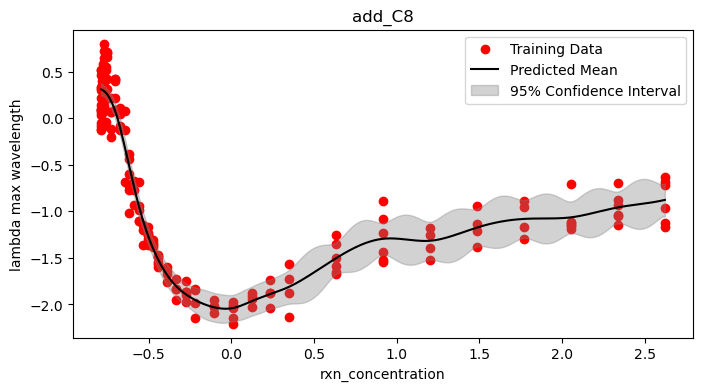

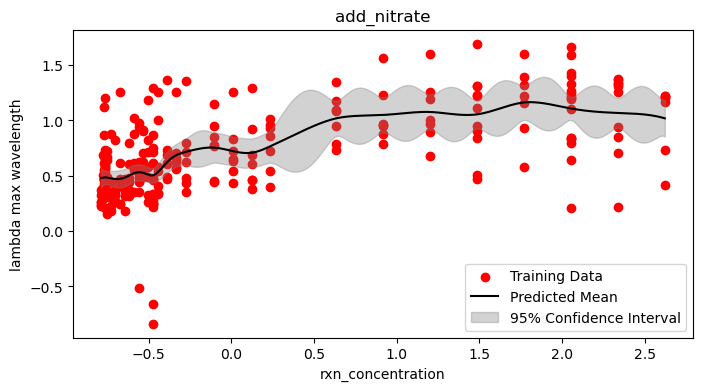

In [12]:
df = pd.read_csv('data/cleaned_data_no_control.csv')

df['rxn_concentration'] = df['concentration'] * df['volume']

x_scaler = StandardScaler()
df['rxn_concentration'] = x_scaler.fit_transform(df[['rxn_concentration']])

y_scaler = StandardScaler()
df['lambda max wavelength'] = y_scaler.fit_transform(df[['lambda max wavelength']])

df = pd.get_dummies(df, columns=['additive'], prefix='add')
additive_cols = [c for c in df.columns if c.startswith("add")]

control_vars = ['rxn_concentration'] + additive_cols

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(0.5, 10.0),
    nu=1.5
)

gp_data = df.copy()

gp = fit_gp(
    gp_data,
    controlVars=control_vars,
    kernel=kernel,
    outputVar='lambda max wavelength',
    noise='constant'
)

plot_gp(
    gp_data,
    gp,
    controlVars=control_vars,
    yVar='lambda max wavelength',
    xVar='rxn_concentration',
)

for add in additive_cols:
    fixedVals = {col: 0 for col in additive_cols}
    fixedVals[add] = 1

    plot_gp(
        gp_data,
        gp,
        controlVars=control_vars,
        yVar='lambda max wavelength',
        xVar='rxn_concentration',
        fixedVals=fixedVals,
        title=add
    )

# Seperate GPs

kernel = 10**2 * Matern(length_scale=0.5, nu=1.5)
C1 kernel: 10**2 * Matern(length_scale=0.5, nu=1.5)
kernel = 10**2 * Matern(length_scale=0.5, nu=1.5)
C4 kernel: 10**2 * Matern(length_scale=0.5, nu=1.5)
kernel = 7.38**2 * Matern(length_scale=0.5, nu=1.5)
C5 kernel: 7.38**2 * Matern(length_scale=0.5, nu=1.5)


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/

kernel = 10**2 * Matern(length_scale=0.5, nu=1.5)
C6 kernel: 10**2 * Matern(length_scale=0.5, nu=1.5)


/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.5. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/audreymarthin/anaconda3/lib/pyth

kernel = 3**2 * Matern(length_scale=0.5, nu=1.5)
C7 kernel: 3**2 * Matern(length_scale=0.5, nu=1.5)
kernel = 10**2 * Matern(length_scale=0.5, nu=1.5)
C8 kernel: 10**2 * Matern(length_scale=0.5, nu=1.5)
kernel = 0.1**2 * Matern(length_scale=1, nu=1.5)
KBr kernel: 0.1**2 * Matern(length_scale=1, nu=1.5)
kernel = 10**2 * Matern(length_scale=0.5, nu=1.5)
nitrate kernel: 10**2 * Matern(length_scale=0.5, nu=1.5)


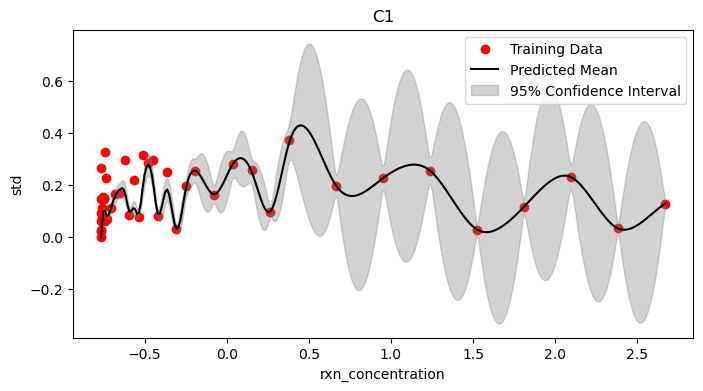

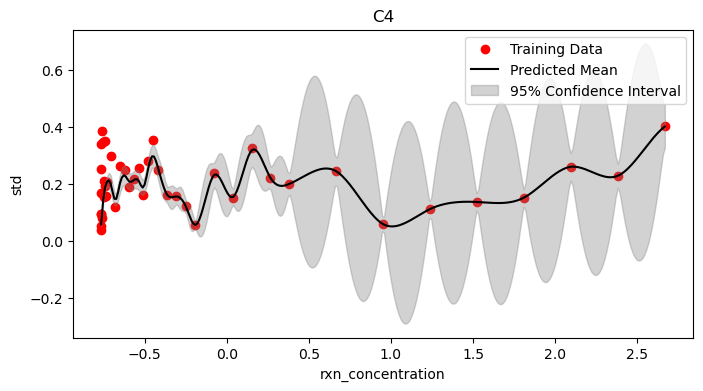

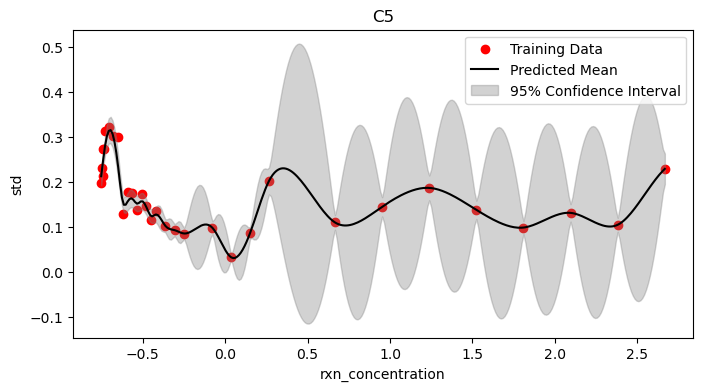

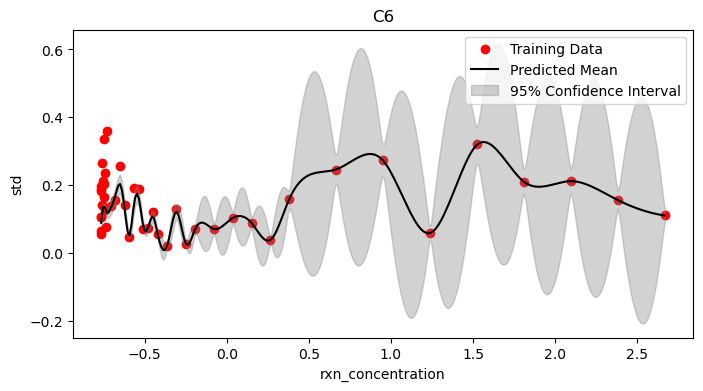

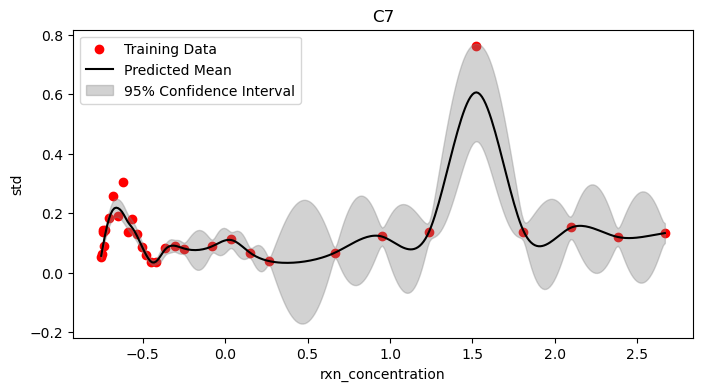

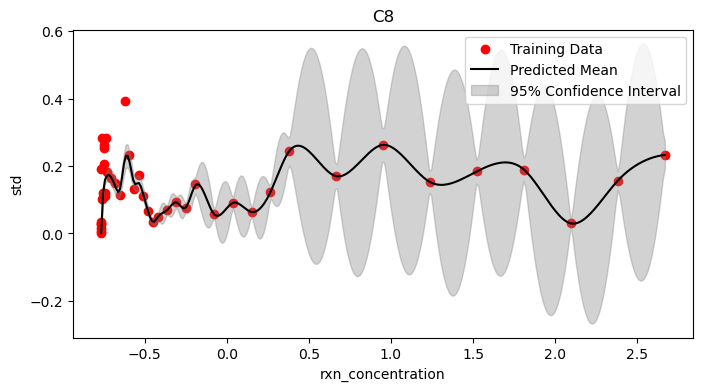

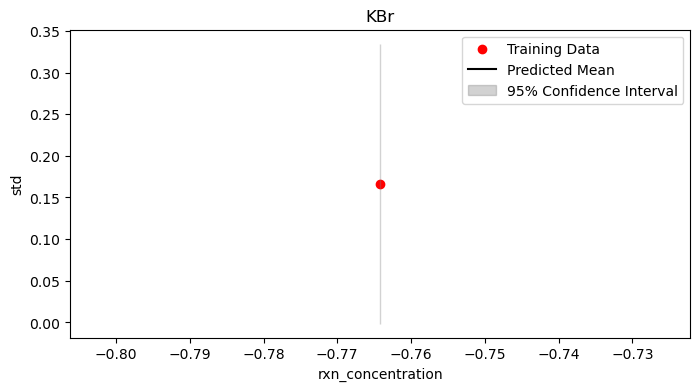

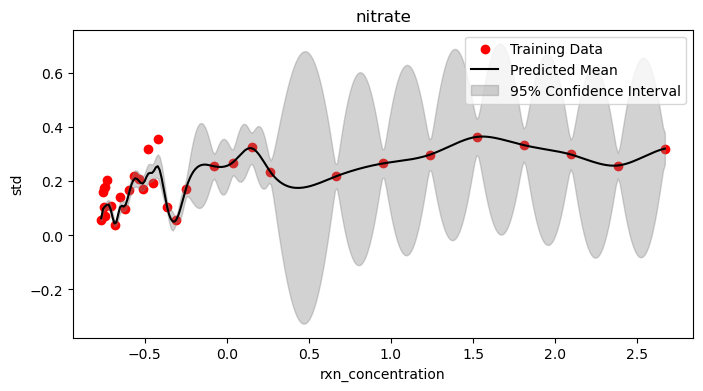

In [18]:
gps = {}

df = pd.read_csv('data/output.csv')

# Feature engineering
df['rxn_concentration'] = df['concentration'] * df['volume']

# Scaling
scaler = StandardScaler()
df['rxn_concentration'] = scaler.fit_transform(df[['rxn_concentration']])

y_scaler = StandardScaler()
df['lambda max wavelength'] = y_scaler.fit_transform(df[['lambda max wavelength']])

kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
    length_scale=1.0,
    length_scale_bounds=(0.5, 10.0),
    nu=1.5
)

gp_data = group(
    data=df,
    controlVars=['rxn_concentration'],
    outputVar='lambda max wavelength',
    blockVar='additive',
    outlierSD=2
)

# Train GP for each block
for additive, block_df in gp_data.items():
    gp = fit_gp(
        df=block_df,
        controlVars=['rxn_concentration'],
        kernel=kernel,
        outputVar='std',
        noise='std'
    )
    gps[additive] = gp

    print(f"{additive} kernel: {gp.kernel_}")
    
for additive, gp in gps.items():
    plot_gp(
        df=gp_data[additive],
        gp=gp,
        controlVars=['rxn_concentration'],
        xVar='rxn_concentration', 
        yVar='std',
        title=additive
    )